# 02 - Data Cleaning
## Credit Risk Analysis — Give Me Some Credit

**Objetivo de este notebook:**
- Eliminar columnas innecesarias
- Tratar los valores nulos de MonthlyIncome y NumberOfDependents
- Identificar y tratar outliers
- Tratar los valores 98 en las columnas de retrasos
- Guardar el dataset limpio en data/processed/

In [2]:
# Importamos librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el dataset
df = pd.read_csv('../data/raw/cs-training.csv')
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## Paso 1: Eliminamos la columna 'Unnamed'

In [3]:
df.drop('Unnamed: 0', axis=1, inplace=True)
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## Paso 1.1: Poner el nombre de las columnas en minúsculas para evitar posibles errores de escritura

In [10]:
df.columns = df.columns.str.lower().str.replace('-', '_')

## Paso 2: Tratamiento de valores nulos en  'MonthlyIncome' y 'NumberOfDependents'
- Había en 'MonthlyIncome'teníamos 29.731 nulos, la mejor manera de tratarlos sería rellenando los datos con la mediana (la media tenía outliers extremos que harían que estos datos distorsionaran mucho)
- En 'NumberOdDependents' habían 3.924 nulos,quizás también debería de aplicar la mediana, porque aunque son "pocos datos", si los eliminamos sería perder datos importantes

In [11]:
df['monthlyincome'] = df['monthlyincome'].fillna(df['monthlyincome'].median())
df['numberofdependents'] = df['numberofdependents'].fillna(df['numberofdependents'].median())

In [12]:
# Verificamos que no haya valores nulos
df.isnull().sum()

seriousdlqin2yrs                        0
revolvingutilizationofunsecuredlines    0
age                                     0
numberoftime30_59dayspastduenotworse    0
debtratio                               0
monthlyincome                           0
numberofopencreditlinesandloans         0
numberoftimes90dayslate                 0
numberrealestateloansorlines            0
numberoftime60_89dayspastduenotworse    0
numberofdependents                      0
dtype: int64

### Resultado
- Los 29.731 nulos de MonthlyIncome se han rellenado con la mediana.
- Los 3.924 nulos de NumberOfDependents se han rellenado con la mediana.
- Se usó la mediana en ambos casos porque es más robusta ante outliers extremos que la media.
- Se evitó inplace=True por incompatibilidad con pandas 3.0.

## Paso 3: Tratamiento de outliers
- 'age' tenía mínimo 0, y máximo 109
- 'revolvingutilizationofunsecuredlines' el máximo tenía que ser entre 0 y 1, y sin embargo tenía el máximo en 50.708
- 'debtratio' tenía un máximo de 329.664
-'numberottime30_59dayspastduenotworse, numberoftime60_89dayspastduenotworse y numberoftimes90dayslate tenían en común que su máximo era 98

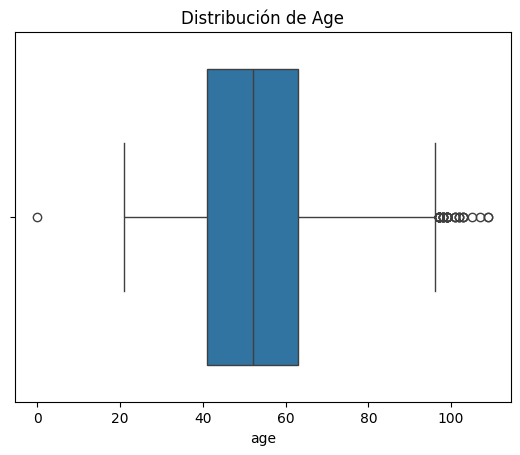

In [13]:
# Hacemos boxplot para identificar outliers en 'age'

sns.boxplot(x=df['age'])
plt.title('Distribución de Age')
plt.show()

## Observaciones de Boxplot de Age:
- En los outliers en edad de 0 años, creo que eran datos con valor desconocido y para que no tuviera dato nulo, pusieron 0, y debería de ser 18 años que es la edad mínima para poder solicitar un crédito.
- En los outliers de edad mayores a 90 años, considero que habría que cambiarlos, porque las "normativas" bancarias no suelen conceder créditos a mayores de 90 años a pesar de que no haya un límite de legal estricto, porque a partir de esas edades se suele considerar modelos de riesgo alto.
- Viendo la gráfica, también se peude ver que LA IQR (la caja) ronda edades entre los 40 y los 60-63 años, con una mediana de 52 años aproximadamente (como se pudo ver en df.describe())
- Para manejar los outliers creo que la decisión más sensata es pasar de 0 años a la edad mínima por ley que son los 18 años, y los outliers superiores rebajarlos a la edad de 90 años, para no pereder filas y porque en pensamiento de negocio tiene mucho sentido aplicar unos límites de edad.

In [14]:
# Contamos cuántas filas tiene edades menos a 18 y mayores a 90 años.
print(df[df['age'] < 18].shape[0])
print(df[df['age'] > 90].shape[0])

1
489


In [16]:
# Ahora sustituimos los valores con 0 años por 18 años.
df.loc[df['age'] < 18, 'age'] = 18

# Hacemos algo parecido con las edades mayores a 90 años, las sustituimos por 90 años.
df.loc[df['age'] > 90, 'age'] = 90

# Revisamos que lo hayamos hecho correctamente.
print(df['age'].min())
print(df['age'].max())

18
90


### age
- Se detectaron 1 valor con edad 0 y 489 con edad mayor de 90.
- Se aplicó capping: valores < 18 sustituidos por 18, valores > 90 sustituidos por 90.
- Límites basados en normativa bancaria: edad mínima para un crédito es 18 años.

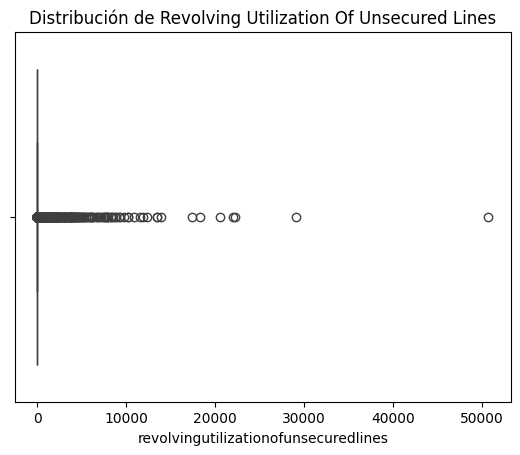

In [18]:
# Hacemos boxplot para identificar outliers en 'revolvingutilizationofunsecuredlines'
sns.boxplot(x=df['revolvingutilizationofunsecuredlines'])
plt.title('Distribución de Revolving Utilization Of Unsecured Lines')
plt.show()

In [20]:
print(df[df['revolvingutilizationofunsecuredlines'] > 1].shape[0])

3321


## Observaciones de Boxplot de Revolving Utilization Of Unsecured Lines
- La variable es un porcentaje y debería estar entre 0 y 1 (Siendo 1,el 100%)
- La mayor concentración de valores está enta entre 0 y 1, donde está la caja (línea gruesa)
- Los outliers extremos llegan hasta 50.708, que en la realidad son datos imposibles
- Hay 3.321 filas con valores por encima de 1
- Aplicamos capping a 1 porque es el límite máximo real de la variable y la que mejor conserva la información de los clientes que tienen un uso muy alto de crédito.

In [21]:
# Ahora sustituimos los valores mayores a 1 por 1.
df.loc[df['revolvingutilizationofunsecuredlines'] > 1, 'revolvingutilizationofunsecuredlines'] = 1

# Revisamos que lo hayamos hecho correctamente.
print(df['revolvingutilizationofunsecuredlines'].max())

1.0


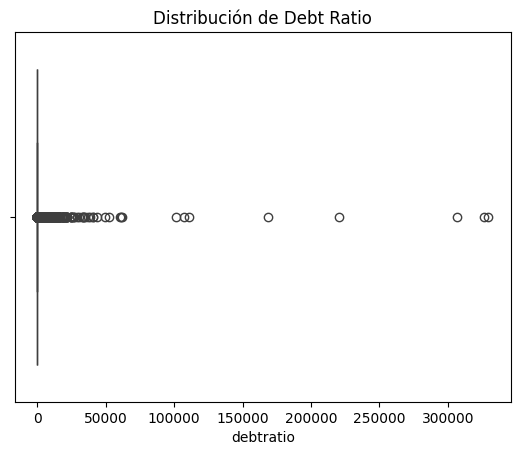

In [22]:
# Hacemos boxplot para ver los outliers en 'debtratio'
sns.boxplot(x=df['debtratio'])
plt.title('Distribución de Debt Ratio')
plt.show()

In [23]:
print(df[df['debtratio'] > 1].shape[0])

35137


In [25]:
Q1 = df['debtratio'].quantile(0.25)
Q3 = df['debtratio'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
print(limite_superior)

1.9080236847499998


## Observaciones de Boxplot de Debt Ratio:
- En este caso, la variable también es un porcentaje y debería tambien estar entre 0 y 1 y mide deuda mensual/ingresos mensuales
- La mayor concentración de valores está entre 0 y 1, pero hay muchos outliers que se esparcen hasta 300.000
- Hay 35.137 filas que superan el 1, lo que nos indica que hay una gran cantidad de outliers. Son valores extremos, pero claramente no son errores.
- Esto lo que nos indica también es que hay muchas personas con sobreendeudamiento (deben más de lo que ingresan) indicando clientes con alto riesgo de impago de créditos
- Esto nos indica que el problema no es que los outliers superen el 1, sino que los valores extremadamente altos. A diferencia del anterior, si es posible un valor mayor porque si que es posible en la vida real un sobreendeudamiento.
- La solución para tantos datos sería de nuevo capping, sustituyendo a 1.91 (límite del valor de outliers en este Boxplot, calculado con el límite estadístico Q3 + 1.5 × IQR) porque es el límite máximo que podemos permitir

In [26]:
# Sustituimos los valores mayores por 1.91
df.loc[df['debtratio']> 1.91, 'debtratio'] = 1.91

# Revisamos que lo hayamos hecho correctamente.
print(df['debtratio'].max())

1.91


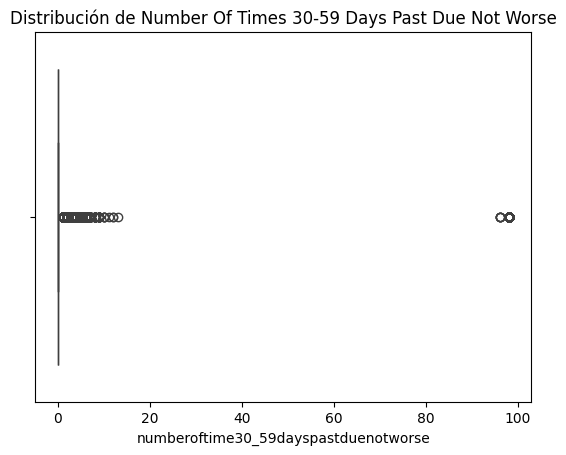

In [29]:
# Boxplot para 'numberoftime30_59dayspastduenotworse'
sns.boxplot(x=df['numberoftime30_59dayspastduenotworse'])
plt.title('Distribución de Number Of Times 30-59 Days Past Due Not Worse')
plt.show()

In [30]:
print(df[df['numberoftime30_59dayspastduenotworse'] >= 96].shape[0])

269


In [31]:
print(df['numberoftime30_59dayspastduenotworse'].median())

0.0


In [32]:
Q1 = df['numberoftime30_59dayspastduenotworse'].quantile(0.25)
Q3 = df['numberoftime30_59dayspastduenotworse'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
print(limite_superior)

0.0


## Observaciones de Boxplot de Number Of Time 30-59 days past due not worse:
- La variable mide número de veces que el prestatario ha tenido un retraso de entre 30 y 59 días en el pago sin que la situación haya empeorado en los 2 últimos años.
- La mayoría de clientes tiene 0 retrasos — la mediana y el percentil 75% son 0. Valores entre 1 y 20 existen pero son minoritarios.
- Hay 269 filas que son los outliers (los dos círculos cerca del 100). Sabemos que son los outliers porque el máximo de retrasos posible era 24, y 98 es imposible y quizás sea una forma de dar valor (rellenar) a los datos nulos 
- Para saber cual es la mejor opción para tratar esas 269 filas calculamos la mediana y el límite superior, estos dos dan 0 así que, hacer capping no valdría de nada, y como son muy pocos datos, creo que lo mejor es eliminar esas 269 filas.

In [33]:
# Eliminado los valores mayores o iguales a 96
df = df[df['numberoftime30_59dayspastduenotworse'] < 96]

# Comprobamos que se hayan eliminado correctamente
print(df['numberoftime30_59dayspastduenotworse'].max())
print(df.shape)

13
(149731, 11)


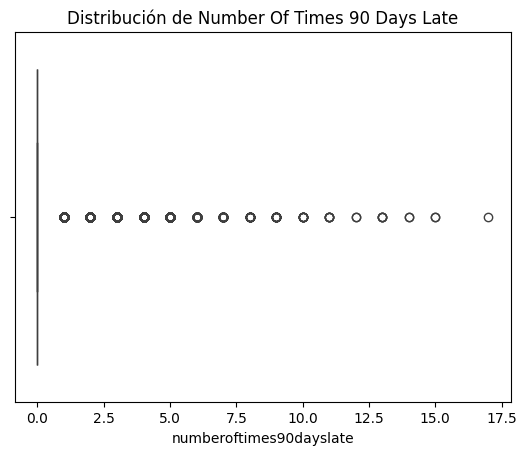

In [34]:
# Boxplot para 'numberoftimes90dayslate'
sns.boxplot(x=df['numberoftimes90dayslate'])
plt.title('Distribución de Number Of Times 90 Days Late')
plt.show()

In [35]:
print(df[df['numberoftimes90dayslate'] >= 96].shape[0])

0


In [36]:
print(df[df['numberoftime60_89dayspastduenotworse'] >= 96].shape[0])

0


## Observaciones de Boxplot de Number Of Times 90 Days Late:
- La caja es muy pequeña, porque la mayoría de cleintes tiene 0 retrasos de +90 días
- Los círculos dispersos entre 1 y 17 son valores pero poco frecuentes (son clientes con retrasos graves)
- El máximo es 17, porque hemos eliminado anteriormente las filas con valores mayores a 98, esas mismas filas también tenían valores 98 en esta columna — confirmando que el valor 98 era algún código especial para evitar que esa filas tuvieran valor nulo.
- No hace falta hacer ninguna limpieza de datos en esta columna 

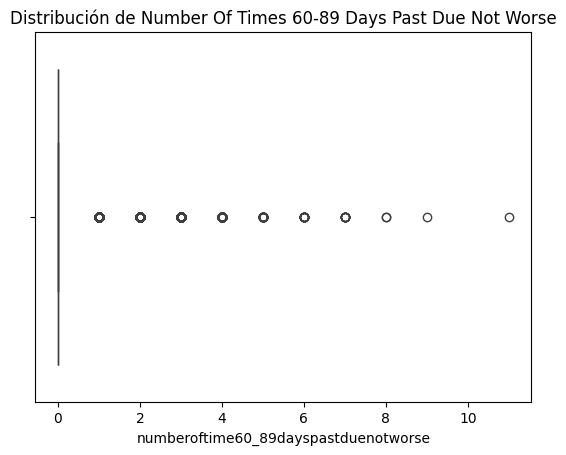

In [37]:
# Boxplot para 'numberoftimes60_89dayspastduenotworse'
sns.boxplot(x=df['numberoftime60_89dayspastduenotworse'])
plt.title('Distribución de Number Of Times 60-89 Days Past Due Not Worse')
plt.show()

## Observaciones del Boxplot de Number of time 60-90 days Past Due Not Worse:
- Ocurre exactamente lo mismo que el gráfico anterior:
- La caja es muy pequeña, porque la mayoría de cleintes tiene 0 retrasos de entre 60-89 días
- Los círculos dispersos entre 1 y 17 son valores pero poco frecuentes (son clientes con retrasos graves)
- El máximo es 11, porque hemos eliminado anteriormente las filas con valores mayores a 98, esas mismas filas también tenían valores 98 en esta columna — confirmando que el valor 98 era algún código especial para evitar que esa filas tuvieran valor nulo.
- No hace falta hacer ninguna limpieza de datos en esta columna.

In [38]:
# Hacemos df.describe() para ver el resultado de la limpieza de datos.
df.describe()

,seriousdlqin2yrs,revolvingutilizationofunsecuredlines,age,numberoftime30_59dayspastduenotworse,debtratio,monthlyincome,numberofopencreditlinesandloans,numberoftimes90dayslate,numberrealestateloansorlines,numberoftime60_89dayspastduenotworse,numberofdependents
count,149731.000000,149731.000000,149731.000000,149731.000000,149731.000000,1.497310e+05,149731.000000,149731.000000,149731.000000,149731.000000,149731.000000
mean,0.065978,0.317973,52.317416,0.245794,0.664499,6.423095e+03,8.467932,0.090456,1.020069,0.064823,0.738150
std,0.248245,0.348601,14.726278,0.697780,0.688730,1.290108e+04,5.138094,0.485527,1.129960,0.330073,1.107375
min,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029771,41.000000,0.000000,0.175998,3.915000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.153491,52.000000,0.000000,0.367119,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.555601,63.000000,0.000000,0.870021,7.400000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,1.000000,90.000000,13.000000,1.910000,3.008750e+06,58.000000,17.000000,54.000000,11.000000,20.000000


## Observaciones:
- Todo está en orden, a excepción de la columna 'monthlyincome' que su máximo sigue siendo 3.008.750.
- Ese valor es un outlier extremo, que quizás habría que habría que hacer capping para poder tener valores más razonables.

In [39]:
Q1 = df['monthlyincome'].quantile(0.25)
Q3 = df['monthlyincome'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
print(limite_superior)

12627.5


In [43]:
# Sustituimos los valores mayores por 12627.5
df.loc[df['monthlyincome'] > 12627.5, 'monthlyincome'] = 12627.5
print(df['monthlyincome'].max())

12627.5


## Observaciones de monthlyincome:
- La variable mide los ingresos mensuales del cliente.
- El máximo original era 3.008.750 — un valor muy alto que distorsionaría el modelo de ML
- Calculamos el límite superior con el método IQR: Q3 + 1.5 × IQR = 12.627.5
- Aplicamos capping: los valores por encima de 12.627.5 se sustituyeron por 12.627.5

In [44]:
# Resumen estadístico final tras la limpieza
df.describe()

,seriousdlqin2yrs,revolvingutilizationofunsecuredlines,age,numberoftime30_59dayspastduenotworse,debtratio,monthlyincome,numberofopencreditlinesandloans,numberoftimes90dayslate,numberrealestateloansorlines,numberoftime60_89dayspastduenotworse,numberofdependents
count,149731.000000,149731.000000,149731.000000,149731.000000,149731.000000,149731.000000,149731.000000,149731.000000,149731.000000,149731.000000,149731.000000
mean,0.065978,0.317973,52.317416,0.245794,0.664499,5879.921356,8.467932,0.090456,1.020069,0.064823,0.738150
std,0.248245,0.348601,14.726278,0.697780,0.688730,3042.690586,5.138094,0.485527,1.129960,0.330073,1.107375
min,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029771,41.000000,0.000000,0.175998,3915.000000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.153491,52.000000,0.000000,0.367119,5400.000000,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.555601,63.000000,0.000000,0.870021,7400.000000,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,1.000000,90.000000,13.000000,1.910000,12627.500000,58.000000,17.000000,54.000000,11.000000,20.000000
